### Análisis de Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dev_path = "data/raw/casas_dev.csv"
test_path = "data/raw/casas_test.csv"

casas_dev_df = pd.read_csv(dev_path)
casas_test_df = pd.read_csv(test_path)

In [3]:
print('shape = ', casas_dev_df.shape)
casas_dev_df.sample(5)

shape =  (900, 9)


,area,area_units,is_house,has_pool,age,price,lat,lon,rooms
824,1033.0,sqft,1,0,19.0,870.0,40.695636,-73.971373,3.0
672,1356.0,sqft,0,0,2.0,1010.0,40.720196,-74.026656,4.0
743,88.0,m2,1,0,12.0,178.0,-34.584929,-58.381594,NaN
879,936.0,sqft,0,0,6.0,690.0,40.712557,-73.998682,2.0
491,904.0,sqft,0,0,12.0,668.0,40.717656,-74.004232,2.0


In [4]:
print('shape = ', casas_test_df.shape)
casas_test_df.sample(5)

shape =  (100, 9)


,area,area_units,is_house,has_pool,age,price,lat,lon,rooms
51,753.0,sqft,0,0,1.0,571.0,40.686219,-73.972013,2.0
17,134.0,m2,0,1,5.0,488.0,-34.604883,-58.379281,4.0
3,96.0,m2,1,0,19.0,168.0,-34.524855,-58.409845,3.0
48,1367.0,sqft,0,0,14.0,924.0,40.729483,-73.976467,4.0
66,1109.0,sqft,0,0,NaN,791.0,40.709839,-73.999404,3.0


# 1) Exploración de datos

El orden de los incisos correspondientes al ejercicio 1 fueron alterados por cuestiones de eficacia y buenas prácticas.

##### 1.1 primera parte) -> analizamos los valores faltantes en los datasets.

In [5]:
from src.utils import missing_percentages, missing_values

In [6]:
print("Dev Set")
missing_values(casas_dev_df)
missing_percentages(casas_dev_df)


Dev Set

Valores faltantes por columna:
area            0
area_units      0
is_house        0
has_pool        0
age           130
price           0
lat             0
lon             0
rooms          72
dtype: int64
Valores NaN en 'age': 130 sobre un total de 900 filas (14.44%)
Valores NaN en 'rooms': 72 sobre un total de 900 filas (8.00%)


Dropear 14.44% y/o 8% de los datos por una feature faltante sería desperdiciar mucha información por lo que intentaremos estimar estos valores faltantes. Para eso, anaelicemos el resto de las features y sus correlaciones.

In [7]:
print("Test Set")
missing_values(casas_test_df)
missing_percentages(casas_test_df)

Test Set

Valores faltantes por columna:
area           0
area_units     0
is_house       0
has_pool       0
age           16
price          0
lat            0
lon            0
rooms          4
dtype: int64
Valores NaN en 'age': 16 sobre un total de 100 filas (16.00%)
Valores NaN en 'rooms': 4 sobre un total de 100 filas (4.00%)


##### Revisión de unidades

In [8]:
print(casas_dev_df['area_units'].value_counts())

area_units
m2      463
sqft    437
Name: count, dtype: int64


Conversión/unificación de unidades

In [9]:
print(casas_test_df['area_units'].value_counts())

area_units
m2      53
sqft    47
Name: count, dtype: int64


In [10]:
from src.preprocessing import area_units_conversion

In [11]:
units_converted_dev_df = area_units_conversion(casas_dev_df)

In [12]:
units_converted_test_df = area_units_conversion(casas_test_df)

In [13]:
units_converted_dev_df.sample(5)

,area,is_house,has_pool,age,price,lat,lon,rooms
171,64.010257,0,0,11.0,516.0,40.709103,-74.002237,2.0
350,68.000000,1,0,14.0,134.0,-34.568413,-58.383659,2.0
337,82.000000,0,1,NaN,171.0,-34.609510,-58.388027,2.0
619,116.000000,0,0,2.0,217.0,-34.645239,-58.351504,4.0
641,71.000000,1,0,9.0,134.0,-34.633590,-58.360475,NaN


Ahora sí podemos visualizar las distribuciones de dev

(resolveremos los valores faltantes NaNs más adelante)

##### 1.2)

In [14]:
from src.plotting import plot_distributions, plot_scatter_matrix, plot_correlation

#### Dev Set

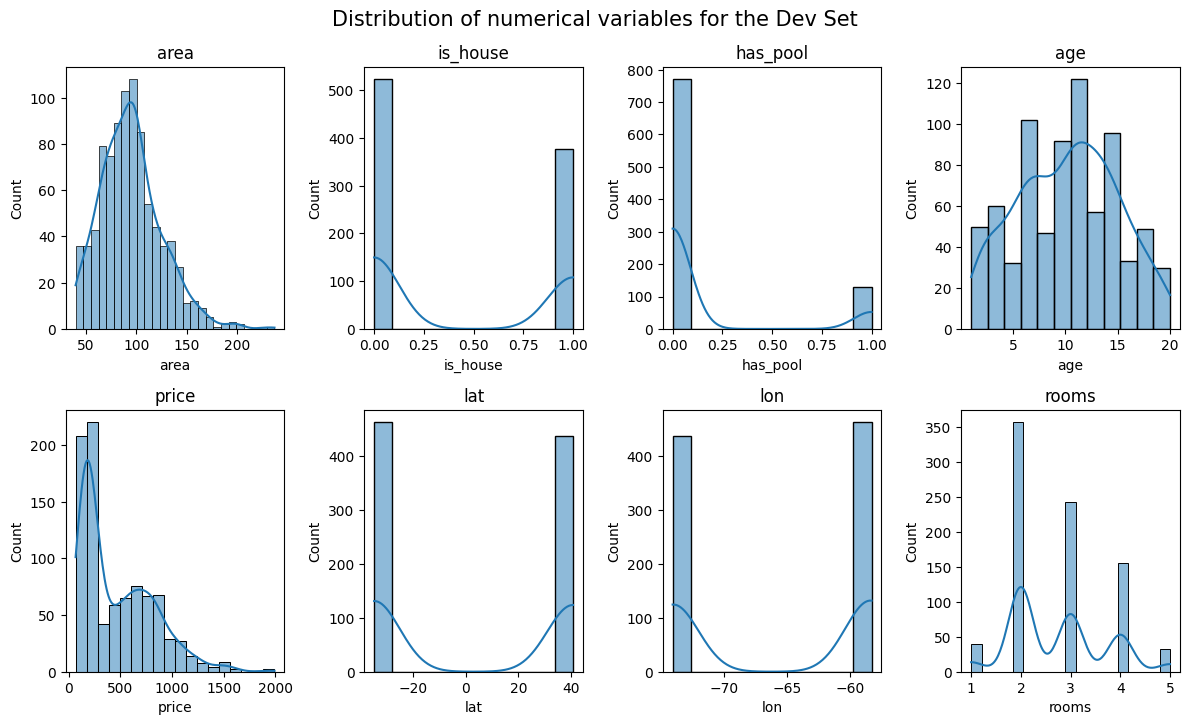

In [15]:
plot_distributions(units_converted_dev_df, "Dev")

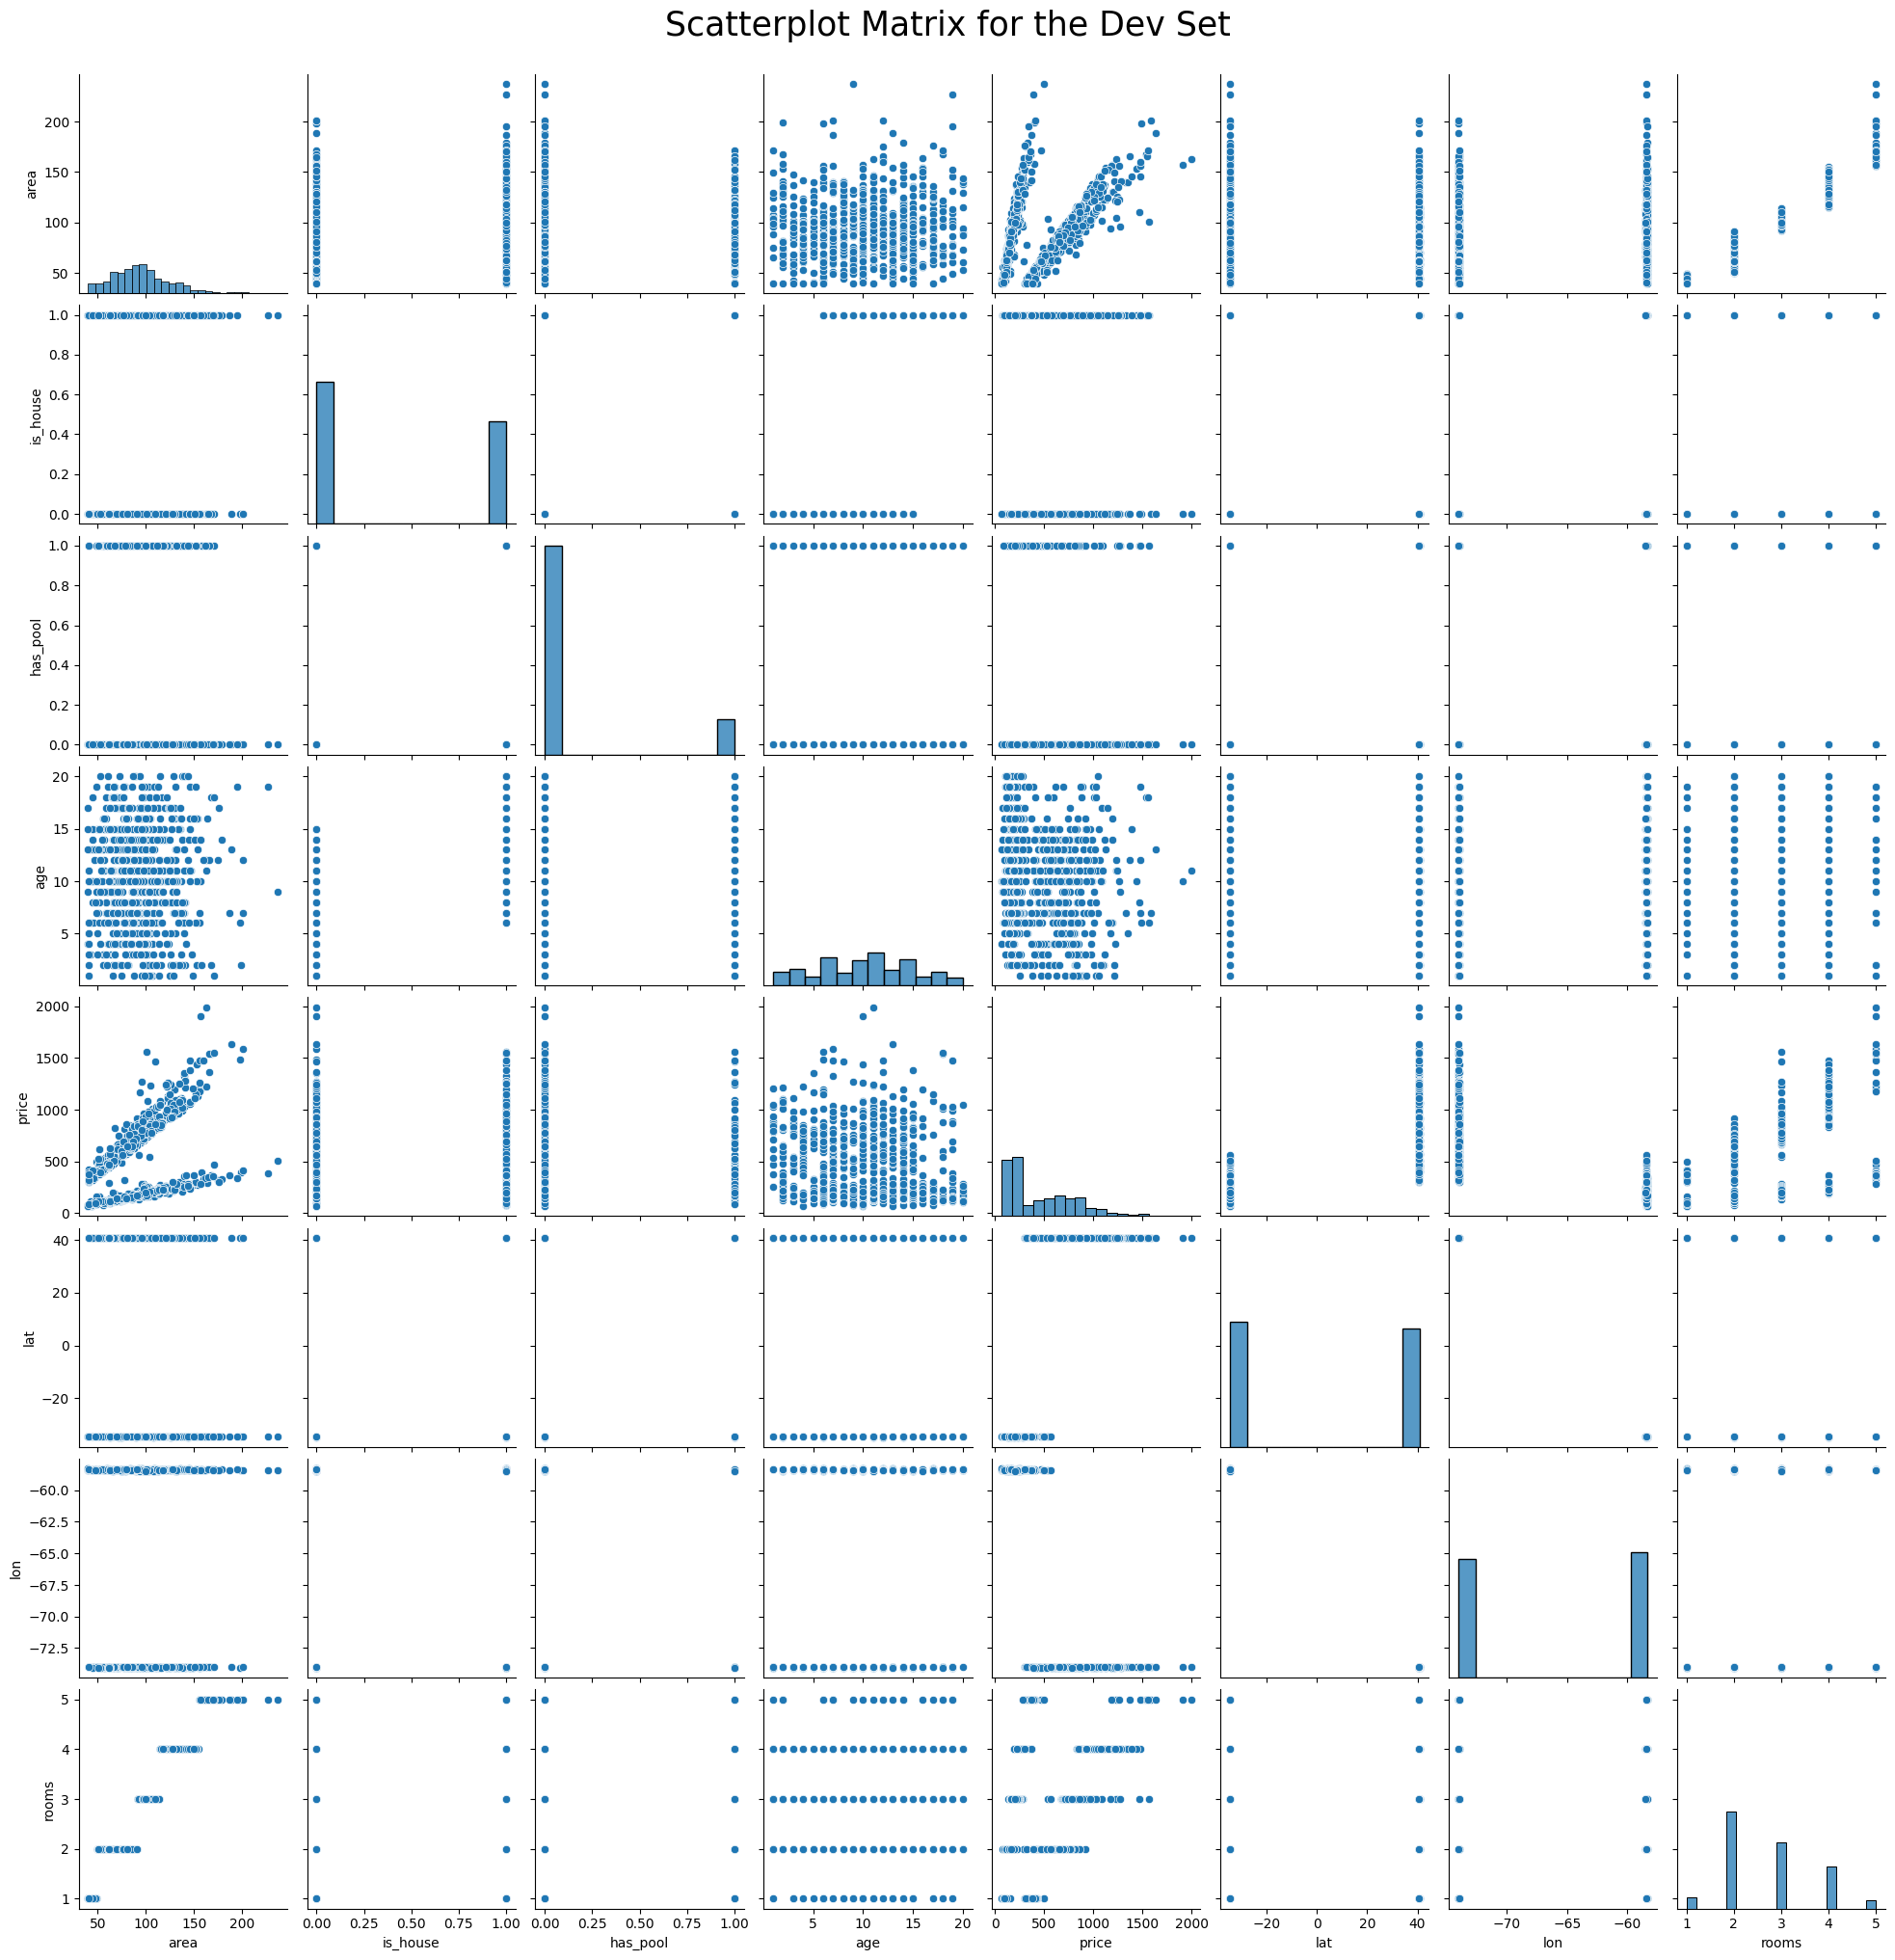

In [16]:
plot_scatter_matrix(units_converted_dev_df, "Dev")

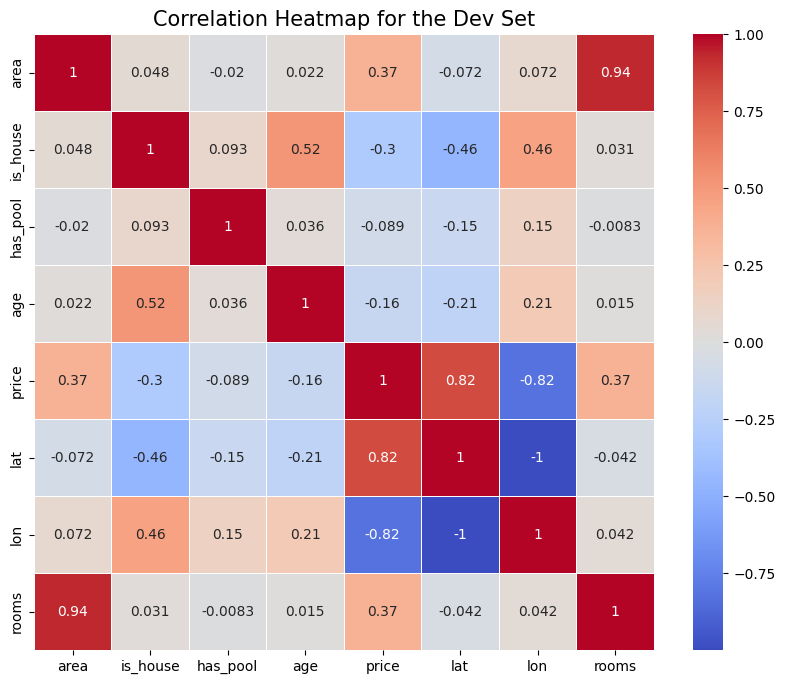

In [17]:
plot_correlation(units_converted_dev_df, "the Dev Set")

#### 1.3) Separación en Train y Validation

Para evitar leaking, separamos el dataset en train y validation antes de estandarizar/escalar los datos y acomodar los valores faltantes.

In [18]:
from src.data_splitting import split_and_save_train_val

In [19]:
casas_train_df, casas_val_df = split_and_save_train_val(units_converted_dev_df, "raw/casas_train.csv", "raw/casas_val.csv")

Train set: 720 rows, Validation set: 180 rows


La idea de estandarización/escalamiento que se va a usar es la siguiente:

#### estandarizamos o escalamos los datos según corresponde

hacemos estandarización (Z-score normalization) cuando asumimos que los datos provienenen de una distribución aproximadamente normal
$$x' = \frac{x - \mu}{\sigma}$$

Y hacemos reescalado cuando cuando los datos no son normales  
Una opción común es Min-Max Scaling:
$$x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

A partir de la observación de la distribución de las variables decido hacer lo siguiente:  

Estandarizo:  
age (aproximadamente normal), rooms (discreta pero la estandarización ayuda)  
(luego de resolver el problema de los NaNs)

Reescalo:   
area y price están sesgadas a la derecha (colas largas)  
la función log anda bien cuando los datos tienen una cola larga hacia la derecha $\rightarrow$ Comprime los valores altos y expande los valores bajos.  
price = log(price + 1) (y hago un ajuste inverso después de la predicción)  
area = log(area + 1) y después estandarizar  
El log hace que los valores grandes no dominen el modelo y mejora la linealidad

o min max...

No hago nada con las binarias: has_pool, is_house  
lat y lon las analizaremos más adelante con feature engenieering

aún no estandarizamos porque al hacer las regresiones para estimar las variables, voy a dividir el dataset de train a su vez en train, validation y test, entonces si estandarizo ahora estaría filtrando información de los datos. Pero dentro de las funciones, esta es la lógica usada para estandarizar los datos para conseguir los valores faltantes.

#### Solucionamos ahora los problemas de nulls

##### Rooms

-> idea: estimo la cantidad de rooms en base al área

visualizo la relación para ver qué regresión usar

In [20]:
from src.plotting import plot_rooms_vs_area

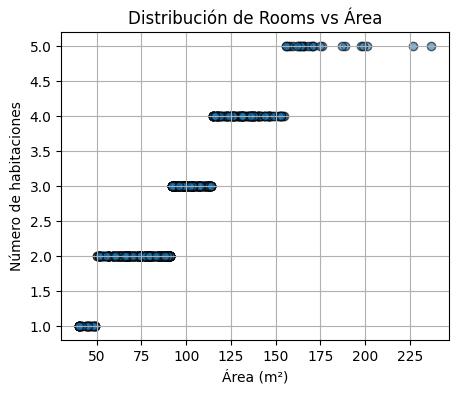

In [21]:
plot_rooms_vs_area(casas_train_df)

In [22]:
from src.models import predict_rooms_train_test, predict_rooms_no_split, complete_missing_rooms_values
from src.utils import missing_values_in_column

In [23]:
# print("Entrenamiento con Train set\n")
# print("divididendo el dataset para tener una métrica de precisión (haciendo split de testeo dentro del dataset de train_df)")
# predict_rooms_train_test(casas_train_df)
# print("\nentrenando con todo el dataset de train_df")
# W_d, b_d, mean_d, std_d = predict_rooms_no_split(casas_train_df)

# # uso los pesos de train para predecir en todos los datasets!!
# print("\nCompletando valores faltantes en todos los datasets con las métricas calculadas a partir de train_df")
# casas_train_rooms_complete = complete_missing_rooms_values(casas_train_df, W_d, b_d, mean_d, std_d)
# casas_val_rooms_complete = complete_missing_rooms_values(casas_val_df, W_d, b_d, mean_d, std_d)
# casas_test_rooms_complete = complete_missing_rooms_values(casas_test_df, W_d, b_d, mean_d, std_d)

# print("\nChequeo")
# print("Train:", missinng_values_in_column(casas_train_rooms_complete, 'rooms'))
# print("Validation:", missinng_values_in_column(casas_val_rooms_complete, 'rooms'))
# print("Test:", missinng_values_in_column(casas_test_rooms_complete, 'rooms'))

print("Entrenamiento con Train set\n")
print("Dividiendo el dataset para tener una métrica de precisión (haciendo split de testeo dentro del dataset de train_df)")
W_d, b_d, mean_d, std_d, min_d, max_d = predict_rooms_train_test(casas_train_df)

print("\nEntrenando con todo el dataset de train_df")
W_d, b_d, mean_d, std_d, min_d, max_d = predict_rooms_no_split(casas_train_df)

# Uso los pesos de train para predecir en todos los datasets
print("\nCompletando valores faltantes en todos los datasets con las métricas calculadas a partir de train_df")
casas_train_rooms_complete = complete_missing_rooms_values(casas_train_df, W_d, b_d, mean_d, std_d, min_d, max_d)
casas_val_rooms_complete = complete_missing_rooms_values(casas_val_df, W_d, b_d, mean_d, std_d, min_d, max_d)
casas_test_rooms_complete = complete_missing_rooms_values(units_converted_test_df, W_d, b_d, mean_d, std_d, min_d, max_d)

print("\nChequeo")
print("Train:", missing_values_in_column(casas_train_rooms_complete, 'rooms'))
print("Validation:", missing_values_in_column(casas_val_rooms_complete, 'rooms'))
print("Test:", missing_values_in_column(casas_test_rooms_complete, 'rooms'))




Entrenamiento con Train set

Dividiendo el dataset para tener una métrica de precisión (haciendo split de testeo dentro del dataset de train_df)
Época 0, Pérdida Train: 0.3219, Pérdida Val: 0.3217
Época 5000, Pérdida Train: 0.1744, Pérdida Val: 0.1648
Época 10000, Pérdida Train: 0.1505, Pérdida Val: 0.1440
Época 15000, Pérdida Train: 0.1357, Pérdida Val: 0.1308
Época 20000, Pérdida Train: 0.1250, Pérdida Val: 0.1212
Época 25000, Pérdida Train: 0.1168, Pérdida Val: 0.1137
Precisión en el conjunto de prueba de train_df: 0.8797

Entrenando con todo el dataset de train_df
Época 0, Pérdida Train: 0.3220, Pérdida Val: 0.3219
Época 5000, Pérdida Train: 0.1700, Pérdida Val: 0.1700
Época 10000, Pérdida Train: 0.1472, Pérdida Val: 0.1456
Época 15000, Pérdida Train: 0.1328, Pérdida Val: 0.1301
Época 20000, Pérdida Train: 0.1224, Pérdida Val: 0.1191
Época 25000, Pérdida Train: 0.1144, Pérdida Val: 0.1108

Completando valores faltantes en todos los datasets con las métricas calculadas a partir de t

verifico que las variables utilizadas normalizadas en la estimación estén en la escala real (area y rooms)

##### Age

estimo las ages que faltan, con aprendizaje supervisado utilizando las features que más correlacion en módulo tienen con age $\rightarrow$ is_house, price, area

In [24]:
from src.plotting import plot_age_vs

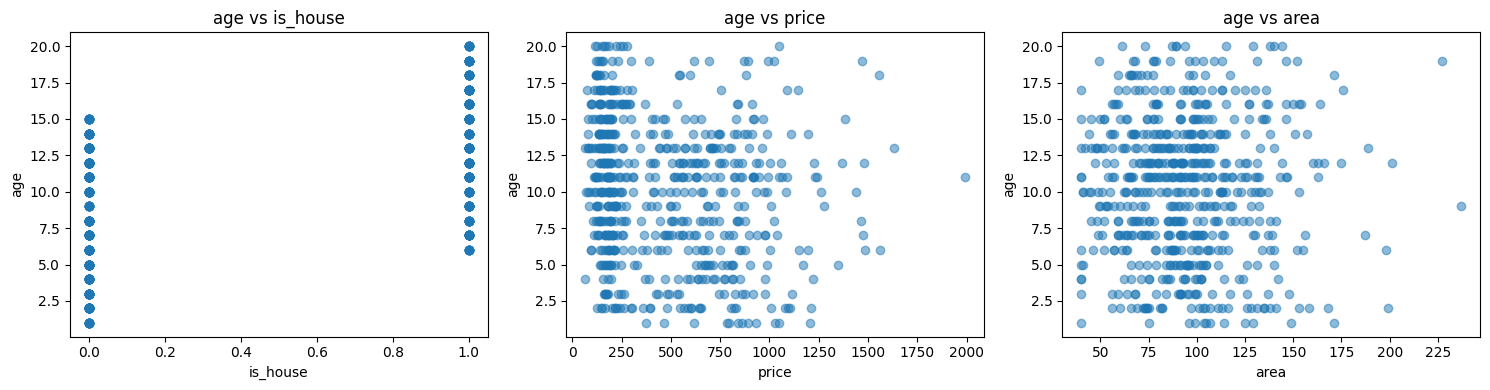

In [25]:
plot_age_vs(casas_train_rooms_complete, features=["is_house", "price", "area"])

In [26]:
from src.models import train_regression_for_age, complete_missing_age_values, evaluate_and_impute


In [27]:
features_seleccionadas = ['is_house', 'price', 'area']

# Indices de columnas para estandarizar/escalar
standardize_cols = []  # No hay columnas que necesiten estandarización (media 0, std 1)
scale_cols = [1, 2]  # 'price' y 'area' necesitan Min-Max Scaling (indices basados en features_seleccionadas)

print("Entrenamiento con Train set\n")
print("Dividiendo el dataset para obtener métricas de precisión (haciendo split dentro de train_df)")
casas_train_rooms_complete = evaluate_and_impute(casas_train_rooms_complete, features_seleccionadas, standardize_cols, scale_cols, grado=1)

# Entrenar con todo el dataset disponible
theta_final, mean_final, std_final, min_final, max_final = train_regression_for_age(
    casas_train_rooms_complete, features_seleccionadas, standardize_cols, scale_cols, grado=1
)

# Imputar valores faltantes en los distintos datasets
casas_train_complete = complete_missing_age_values(
    casas_train_rooms_complete, theta_final, mean_final, std_final, min_final, max_final, features_seleccionadas, standardize_cols, scale_cols, grado=1
)
casas_val_complete = complete_missing_age_values(
    casas_val_rooms_complete, theta_final, mean_final, std_final, min_final, max_final, features_seleccionadas, standardize_cols, scale_cols, grado=1
)
casas_test_complete = complete_missing_age_values(
    casas_test_rooms_complete, theta_final, mean_final, std_final, min_final, max_final, features_seleccionadas, standardize_cols, scale_cols, grado=1
)


Entrenamiento con Train set

Dividiendo el dataset para obtener métricas de precisión (haciendo split dentro de train_df)
Train RMSE: 4.0405
Validation RMSE: 3.7051
Test RMSE: 4.2650
107 valores faltantes en 'age' completados.
No hay valores faltantes en 'age'.
23 valores faltantes en 'age' completados.
16 valores faltantes en 'age' completados.


In [28]:
casas_train_complete.sample(15)

,area,is_house,has_pool,age,price,lat,lon,rooms
307,94.017968,0,0,9.0,689.0,40.720028,-73.952875,3.0
149,113.000000,1,0,17.0,196.0,-34.585988,-58.415250,3.0
749,75.000000,1,0,12.0,136.0,-34.681287,-58.404594,2.0
259,103.029571,0,0,2.0,820.0,40.723008,-73.988080,3.0
781,159.979190,1,0,12.0,1480.0,40.743194,-74.018666,3.0
879,86.957330,0,0,6.0,690.0,40.712557,-73.998682,2.0
836,85.006364,0,0,8.0,665.0,40.706793,-74.000989,2.0
254,90.000000,1,0,13.0,156.0,-34.686202,-58.375785,2.0
352,68.005091,0,0,8.0,506.0,40.691322,-73.965570,2.0
30,104.980537,0,0,5.0,814.0,40.720312,-73.996595,3.0


In [29]:
print("Valores faltantes después de la imputación:")
print("Train")
missing_values(casas_train_complete)
print("Validation")
missing_values(casas_val_complete)  
print("Test")
missing_values(casas_test_complete)

Valores faltantes después de la imputación:
Train

Valores faltantes por columna:
area        0
is_house    0
has_pool    0
age         0
price       0
lat         0
lon         0
rooms       0
dtype: int64
Validation

Valores faltantes por columna:
area        0
is_house    0
has_pool    0
age         0
price       0
lat         0
lon         0
rooms       0
dtype: int64
Test

Valores faltantes por columna:
area        0
is_house    0
has_pool    0
age         0
price       0
lat         0
lon         0
rooms       0
dtype: int64


In [30]:
age_comparison = casas_test_df['age'] == casas_test_complete['age']
rooms_comparison = casas_test_df['rooms'] == casas_test_complete['rooms']

print("Comparación de la columna 'age':")
print(age_comparison.value_counts())  

print("\nComparación de la columna 'rooms':")
print(rooms_comparison.value_counts())

print("\nFilas donde 'age' no coincide:")
print(casas_test_df[~age_comparison])

print("\nFilas donde 'rooms' no coincide:")
print(casas_test_df[~rooms_comparison])

Comparación de la columna 'age':
age
True     84
False    16
Name: count, dtype: int64

Comparación de la columna 'rooms':
rooms
True     96
False     4
Name: count, dtype: int64

Filas donde 'age' no coincide:
      area area_units  is_house  has_pool  age   price        lat        lon  \
13   667.0       sqft         0         0  NaN   480.0  40.708612 -74.023947   
16   926.0       sqft         0         0  NaN   642.0  40.723940 -73.988968   
28    89.0         m2         1         0  NaN   161.0 -34.537603 -58.385514   
32   678.0       sqft         0         0  NaN   470.0  40.739068 -73.982893   
41   129.0         m2         1         0  NaN   225.0 -34.562169 -58.404882   
60    97.0         m2         1         0  NaN   188.0 -34.557143 -58.372201   
62  1023.0       sqft         0         0  NaN   747.0  40.689159 -74.007984   
63    79.0         m2         0         0  NaN   124.0 -34.632125 -58.444064   
66  1109.0       sqft         0         0  NaN   791.0  40.709839 -73

está bien, solo difieren en los que eran NaNs

In [31]:
casas_test_df['age'] = casas_test_complete['age']
casas_test_df['rooms'] = casas_test_complete['rooms']
# el set de test es el original, con las columnas de 'age' y 'rooms' completadas en los valores NaNs

ahora sí normalizamos train y validation

In [32]:
from src.preprocessing import compute_statistics, scale_df

In [33]:
train_stats = compute_statistics(casas_train_df)

casas_train_transformed = scale_df(casas_train_df, train_stats)
casas_val_transformed = scale_df(casas_val_df, train_stats) # uso las estadísticas de train!!!

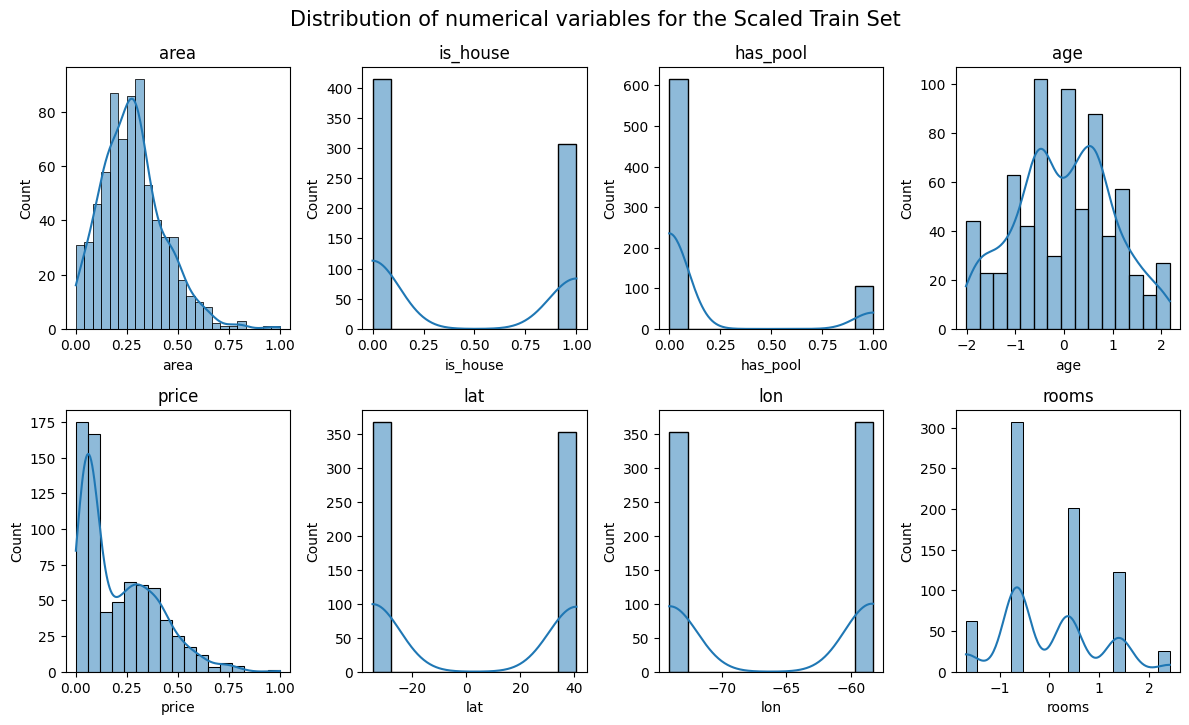

In [34]:
plot_distributions(casas_train_transformed, "Scaled Train")

(área y price siguen la misma distribución pero están entre 0 y 1)

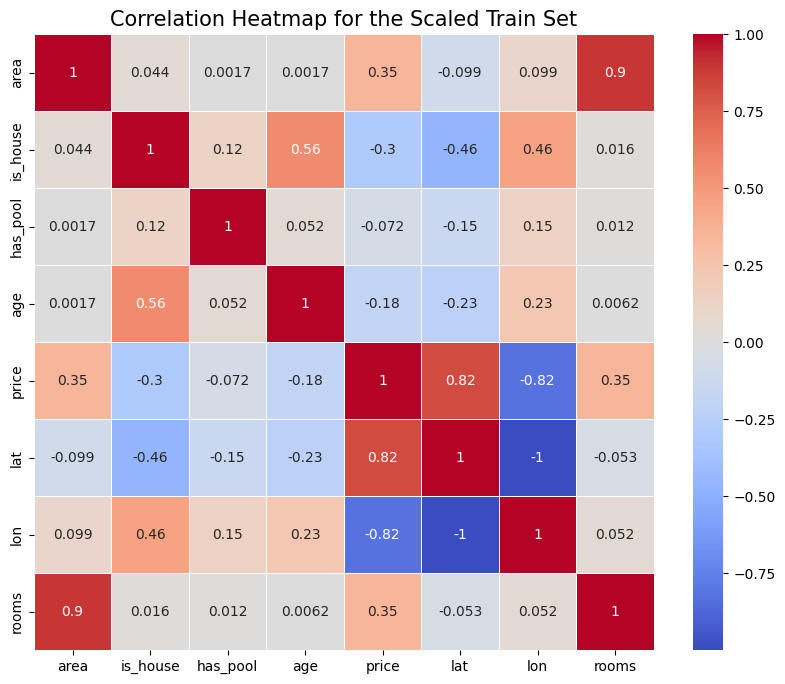

In [35]:

plot_correlation(casas_train_transformed, "the Scaled Train Set")

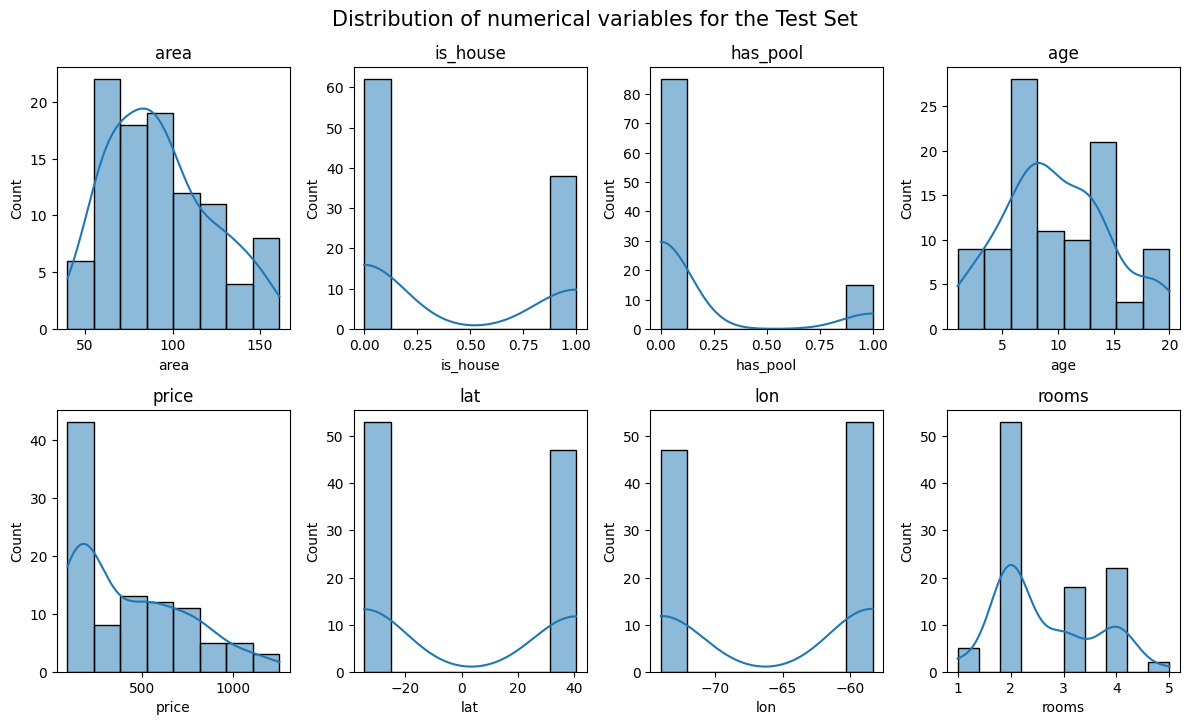

In [36]:
plot_distributions(casas_test_complete, "Test")

In [37]:
from src.utils import save_csv

save_csv(casas_train_transformed, "data/processed/casas_train_filled_n_normalized.csv")
save_csv(casas_val_transformed, "data/processed/casas_val_filled_n_normalized.csv")

save_csv(casas_train_df, "data/processed/casas_train_filled.csv")
save_csv(casas_val_df, "data/processed/casas_val_filled.csv")
save_csv(casas_test_df, "data/processed/casas_test_filled.csv")


Dataset guardado como 'data/processed/casas_train_filled_n_normalized.csv'.
Dataset guardado como 'data/processed/casas_val_filled_n_normalized.csv'.
Dataset guardado como 'data/processed/casas_train_filled.csv'.
Dataset guardado como 'data/processed/casas_val_filled.csv'.
Dataset guardado como 'data/processed/casas_test_filled.csv'.


## 2)

2.1) implementación de la clase Linear Regression en src.models

2.2) implementación de RMSE en src.metrics

##### 2.3)

In [38]:
from src.models import LinearRegression
from src.utils import load_data

In [39]:
dir_base = "data/processed/"
train_path = dir_base + "casas_train_filled_n_normalized.csv"
validation_path = dir_base + "casas_val_filled_n_normalized.csv"
test_path = dir_base + "casas_test_filled.csv"

def use_test(test_path):
    test = pd.read_csv(test_path)
    test = area_units_conversion(test)
    test = scale_df(test, train_stats, True)
    return test

test = use_test(test_path)

features = ["area", "is_house", "has_pool", "age", "lat", "lon", "rooms"] 
target = "price"

X_train, y_train = load_data(train_path, None, features, target)
X_val, y_val = load_data(validation_path, None, features, target)
X_test, y_test = load_data("", test, features, target, True)



#### Prueba con una característica

In [40]:
X_train_1 = X_train[:, [0]]  # solo area
X_val_1 = X_val[:, [0]]  
X_test_1 = X_test[:, [0]]

In [41]:
modelo_pseudo_multi = LinearRegression(X_train, y_train, X_val, y_val, train_stats)
modelo_pseudo_multi.entrenar_pseudoinversa()
modelo_pseudo_multi.evaluar(X_test, y_test)


Error cuadrático medio (MSE) en test: 12373.5585


12373.558474124568

##### Pseudoinversa

Error cuadrático medio (MSE) en test: 84953.1090


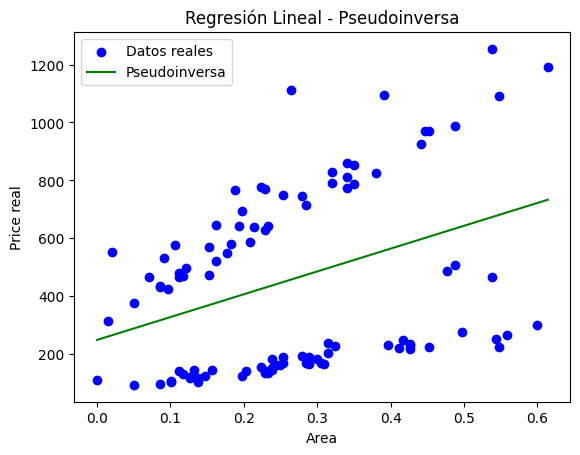

In [42]:
modelo_pseudo = LinearRegression(X_train_1, y_train, X_val_1, y_val, train_stats)
modelo_pseudo.entrenar_pseudoinversa()
modelo_pseudo.evaluar(X_test_1, y_test)
modelo_pseudo.graficar_regresion_pseudoinversa(X_test_1, y_test, ["Area"])

##### Descenso por gradiente

In [ ]:
modelo_gradiente = LinearRegression(X_train_1, y_train, X_val_1, y_val, train_stats)
modelo_gradiente.entrenar_descenso_gradiente(lr=0.01, epochs=5000)
modelo_gradiente.evaluar(X_test_1, y_test)
modelo_gradiente.graficar_regresion_descenso_gradiente(X_test_1, y_test, ["Area"])
modelo_gradiente.graficar_perdida()

Early stopping en epoch 1568


TypeError: 'NoneType' object is not subscriptable

#### Prueba con múltiples características

##### Pseudoinversa

In [ ]:
modelo_pseudo_multi = LinearRegression(X_train, y_train, X_val, y_val)
modelo_pseudo_multi.entrenar_pseudoinversa()
modelo_pseudo_multi.evaluar(X_test, y_test)

Error cuadrático medio (MSE) en test: 0.0033


0.003332200964181888

##### Descenso por gradiente

Early stopping en epoch 266
Error cuadrático medio (MSE) en test: 0.0077


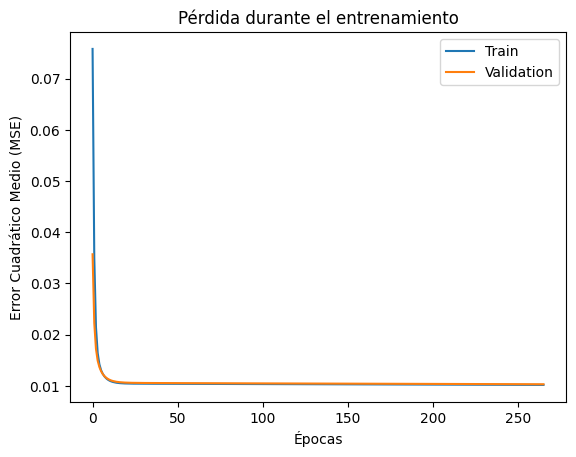

In [ ]:
modelo_gradiente_multi = LinearRegression(X_train, y_train, X_val, y_val)
modelo_gradiente_multi.entrenar_descenso_gradiente(lr=0.0001, epochs=5000)
modelo_gradiente_multi.evaluar(X_test, y_test)
modelo_gradiente_multi.graficar_perdida()


en ambos casos, el método de la pseudoinversa tiene menos Error Cuadrático Medio en el set de test

### 3)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


amanda_path = 'data/raw/vivienda_Amanda.csv'

dir_base = "data/processed/"
train_path = dir_base + "casas_train_filled_n_normalized.csv"
validation_path = dir_base + "casas_val_filled_n_normalized.csv"
test_path = dir_base + "casas_test_filled_n_normalized.csv"


# 3.1) Regresión lineal simple (Área -> Precio)
X_train, y_train, df_train = load_data(train_path, ['area'], 'price')

# Ajustar el modelo por pseudo-inversa
X_train_bias = np.hstack((np.ones((X_train.shape[0], 1)), X_train))
coef_simple = np.linalg.pinv(X_train_bias) @ y_train

print("Coeficientes (Área -> Precio):", coef_simple)

# Graficar la regresión
plt.scatter(X_train, y_train, color='blue', label='Datos reales')
plt.plot(X_train, X_train_bias @ coef_simple, color='red', label='Regresión')
plt.xlabel('Área')
plt.ylabel('Precio')
plt.title('Regresión Lineal Simple (Área -> Precio)')
plt.legend()
plt.show()

# 3.2) Modelo con múltiples características
features = ['area', 'rooms', 'is_house', 'has_pool']
X_train, y_train, df_train = load_data(train_path, features, 'price')
X_test, _, df_test = load_data(test_path, features, 'price')
X_amanda, _, _ = load_data(amanda_path, features, 'price')

X_train_bias = np.hstack((np.ones((X_train.shape[0], 1)), X_train))
coef_multi = np.linalg.pinv(X_train_bias) @ y_train

print("Coeficientes (Modelo Completo):", coef_multi)

# Predicción para vivienda_Amanda
X_amanda_bias = np.hstack((np.ones((X_amanda.shape[0], 1)), X_amanda))
precio_amanda = X_amanda_bias @ coef_multi
print("Predicción para vivienda Amanda:", precio_amanda)

# 3.3) Valor promedio por metro cuadrado
df_casas = pd.read_csv(train_path)
df_casas = df_casas[df_casas['is_house'] == 1]  # Solo casas
precio_m2 = df_casas['price'] / df_casas['area']
print("Valor promedio por metro cuadrado de una casa:", precio_m2.mean())

# 3.4) Impacto de una pileta en el precio
# Consideramos el coeficiente asociado a 'has_pool'
impacto_pileta = coef_multi[features.index('has_pool') + 1]
print("Impacto estimado de construir una pileta en el precio:", impacto_pileta)


TypeError: load_data() missing 1 required positional argument: 'target'

In [ ]:
vivienda_Amanda_df = pd.read_csv(amanda_path)
# units_vivienda_Amanda_df = area_units_conversion(vivienda_Amanda_df)
# vivienda_Amanda_scaled = scale_df(units_vivienda_Amanda_df)
# # vivienda_Amanda_transformed = pca_latlon(vivienda_Amanda_scaled)
# vivienda_Amanda_scaled.head(1)
# # vivienda_Amanda_scaled = scale_df(units_vivienda_Amanda_df, missing_values=True)



# # guardar_csv(vivienda_Amanda_transformed, "vivienda_Amanda_corregido.csv")

TypeError: scale_df() missing 1 required positional argument: 'stats'